## Import Required Libraries and Setting Folder Structure

In [1]:
# Basic Packages
from pathlib import Path
import random
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dimensionality Reduction
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Project Folders
CURRENT_DIR = Path.cwd()

# Root Folder
ROOT_DIR = CURRENT_DIR.parents[1]

DATASET_DIR = ROOT_DIR / "results" / "module_2" / "dataset_creation"
RESULTS_DIR = ROOT_DIR / "results" / "module_2" / "clustering"
PLOTS_DIR = ROOT_DIR / "plots" / "module_2" / "clustering"

# Create Output Folders if they do not already exist
RESULTS_DIR.mkdir(parents=True, exist_ok = True)
PLOTS_DIR.mkdir(parents=True, exist_ok = True)

print("Project root:", ROOT_DIR)
print("Dataset folder:", DATASET_DIR)
print("Results folder:", RESULTS_DIR)
print("Plots folder:", PLOTS_DIR)
print("Random seed:", RANDOM_SEED)

Project root: C:\Users\samsa\Documents\ICU Clustering
Dataset folder: C:\Users\samsa\Documents\ICU Clustering\results\module_2\dataset_creation
Results folder: C:\Users\samsa\Documents\ICU Clustering\results\module_2\clustering
Plots folder: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\clustering
Random seed: 42


## Load and Verify the Final Clustering Dataset

In [2]:
# Path to the Final Clustering Dataset
DATASET_PATH = DATASET_DIR/"feature_data_scaled.csv"

# Load the Dataset
feature_data = pd.read_csv(DATASET_PATH)

# Separate the patient identifier from clustering features
patient_ids = feature_data["patientunitstayid"]

feature_columns = [
    column
    for column in feature_data.columns
    if column != "patientunitstayid"
]

X = feature_data[feature_columns]

# Basic Checking
print(f"Dataset Shape : {feature_data.shape}")
print(f"Number of Patients : {len(feature_data)}")
print(f"Number of Clustering Features : {X.shape[1]}")

print(f"Duplicate Patient Ids : {patient_ids.duplicated().sum()}")
print(f"Missing Values : {X.isna().sum().sum()}")
print("Infinite values:", np.isinf(X.to_numpy()).sum())

print("Minimum feature value:", X.min().min())
print("Maximum feature value:", X.max().max())

Dataset Shape : (7648, 81)
Number of Patients : 7648
Number of Clustering Features : 80
Duplicate Patient Ids : 0
Missing Values : 0
Infinite values: 0
Minimum feature value: 0.0
Maximum feature value: 1.0000000000000002


#### Observation :

The final clustering dataset is ready for analysis.
- There are $7,648$ patients and $80$ clustering features.
- Every patient ID is unique, so each row represents one patient.
- There are no missing or infinite values which means t-SNE, UMAP, VAE and DBSCAN can work directly with this matrix.
- The feature values range from `0.0` to approximately `1.0` confirming that Min-Max scaling was applied correctly.
- The value `1.0000000000000002` is only a small floating-point precision effect and can be treated as `1.0`.

# Dimensionality Reduction

## Create a Two-Dimensional t-SNE Representation

In [3]:
# Create the t-SNE model
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    metric="euclidean",
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    random_state=RANDOM_SEED
)

# Fit t-SNE and create the 2D representation
tsne_coordinates = tsne_model.fit_transform(X)

# Store the coordinates with patient IDs
tsne_embedding = pd.DataFrame({
    "patientunitstayid": patient_ids.values,
    "tsne_1": tsne_coordinates[:, 0],
    "tsne_2": tsne_coordinates[:, 1]
})

# Save the embedding
tsne_embedding.to_csv(
    RESULTS_DIR / "tsne_embedding.csv",
    index=False
)

print("t-SNE embedding shape:", tsne_embedding.shape)
print()
print(tsne_embedding.head())

t-SNE embedding shape: (7648, 3)

   patientunitstayid     tsne_1     tsne_2
0             151900 -69.437340   2.642728
1             210208 -58.957081  14.864347
2             179269  21.402903  21.252129
3             172764  12.093176  20.938839
4             166175  26.010063 -36.307499


#### Observation :

The t-SNE transformation completed successfully.
- All $7,648$ patients received two t-SNE coordinates.
- The output has the expected $7,648$ rows and $3$ columns : `patientunitstayid`, `tsne_1` and `tsne_2`.
- Negative and positive coordinate values are completely normal. The numbers themselves do not represent clincial measurements. What matters is whether patients with similar $80-$ feature profiles appear close together in this two-dimensional space.
- From only first five rows, we cannot determine whether clear patient groups exist. We need to visualize all $7,648$ patients before making that conclusion.

## Visualize the t-SNE Patient Representation

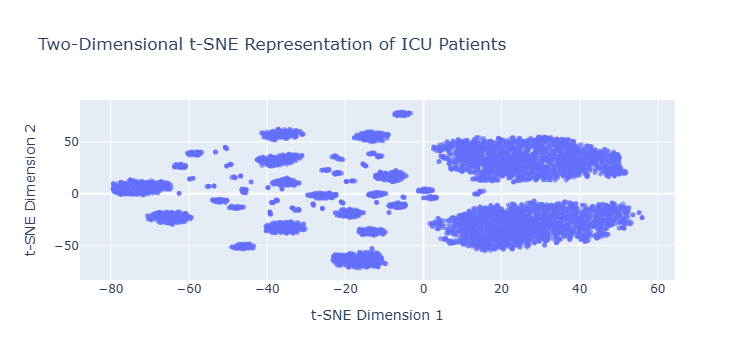

t-SNE plot saved as: tsne_embedding.html


In [4]:
# Create the interactive t-SNE scatter plot
fig = px.scatter(
    tsne_embedding,
    x="tsne_1",
    y="tsne_2",
    hover_data=["patientunitstayid"],
    title="Two-Dimensional t-SNE Representation of ICU Patients"
)

# Improve readability
fig.update_traces(
    marker=dict(
        size=5,
        opacity=0.65
    )
)

fig.update_layout(
    xaxis_title="t-SNE Dimension 1",
    yaxis_title="t-SNE Dimension 2"
)

# Display the plot
fig.show()

# Save the interactive plot
fig.write_html(
    PLOTS_DIR / "tsne_embedding.html"
)

print("t-SNE plot saved as: tsne_embedding.html")

#### Observation :
The t-SNE embedding shpws that the patients are not distributed randomly.Several dense and clearly separated regions are visible.

Two large patient groups appear on the right side of the plot while many smaller groups appear across the center and left side. There are also noticeable gaps between many of these regions, which suggests that patients with similar clinical feature patterns may be forming natural groups.

A few very small isolated regions are also present which could later become small clusters or DBSCAN outliers.

At this tage, these regions should not yet be treated as confirmed clusters. t-SNE is mainly showing the structure of the $80$- dimensional patient data in two dimensions. DBSCAN will later determine which dense regions actually qualify as clusters and which observations should be labeled as noise.

## Create a Two-Dimensional UMAP Representation

In [5]:
# Create the UMAP Model
umap_model = UMAP(
    n_components = 2,
    n_neighbors = 15,
    min_dist = 0.1,
    metric = "euclidean",
    n_jobs = -1,
    random_state=RANDOM_SEED
)

# Fit UMAP and Create the 2D Representation
umap_coordinates = umap_model.fit_transform(X)

# Store the coordinates with patient IDs
umap_embedding = pd.DataFrame({
    "patientunitstayid": patient_ids.values,
    "umap_1": umap_coordinates[:, 0],
    "umap_2": umap_coordinates[:, 1]
})

# Save the embedding
umap_embedding.to_csv(
    RESULTS_DIR / "umap_embedding.csv",
    index=False
)

print("UMAP embedding shape:", umap_embedding.shape)
print()
print(umap_embedding.head())

UMAP embedding shape: (7648, 3)

   patientunitstayid     umap_1     umap_2
0             151900  21.968367  -3.120085
1             210208  13.741985  -5.261218
2             179269  -0.063994  11.446985
3             172764  -0.102522  10.802602
4             166175  -2.755549  -6.008907


#### Observation :
The UMAP transformation completed successfully.
- All $7,648$ patients received two UMAP coordinates.
- The output has the expected $7,648$ rows and $3$ columns.
- The coordinate values are on a different scale from t-SNE which is normal.
- As with t-SNE, the coordinate numbers themselves do not have clinical meaning. What matters is how patients are positioned relative to one another.
- We now need to visualize the full UMAP embedding to see whether it forms dense and separated patient regions similar to the paper.

## Visualize the UMAP Patient Representation

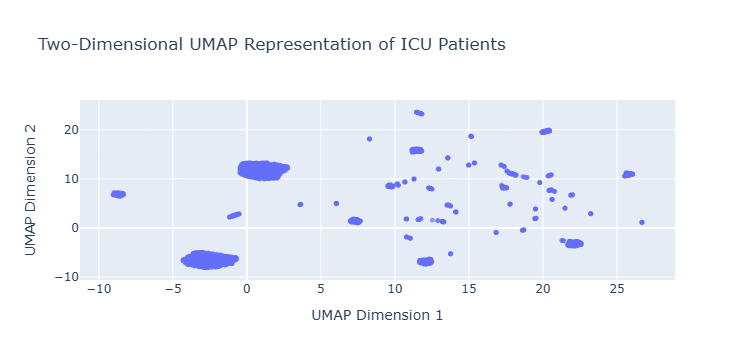

UMAP plot saved as: umap_embedding.html


In [6]:
# Create the interactive UMAP scatter plot
fig = px.scatter(
    umap_embedding,
    x="umap_1",
    y="umap_2",
    hover_data=["patientunitstayid"],
    title="Two-Dimensional UMAP Representation of ICU Patients"
)

# Improve readability
fig.update_traces(
    marker=dict(
        size=5,
        opacity=0.65
    )
)

fig.update_layout(
    xaxis_title="UMAP Dimension 1",
    yaxis_title="UMAP Dimension 2"
)

# Display the plot
fig.show()

# Save the interactive plot
fig.write_html(
    PLOTS_DIR / "umap_embedding.html"
)

print("UMAP plot saved as: umap_embedding.html")

#### Observation :
The UMAP representation shows clear separation between several patient regions.

Two large and very dense groups appear on the left side of the plot, while many smaller compact groups are spread across the center and right side. There are noticeable empty spaces between most of these regions, which suggests that UMAP is preserving distinct patient structures in the $80$-feature dataset.

Compared with the t-SNE plot, the UMAP groups appear more compact and more clearly separated. This is encouraging for DBSCAN because density-based clustering works well when dense groups are separated by lower-density areas.

## Build and Train a Two-Dimensional Variational Autoencoder

We will use the same $80$ scaled patient features and compress them into two latent dimensions :
```
80 features
    ↓
64 neurons
    ↓
32 neurons
    ↓
2 latent dimensions
    ↓
32 neurons
    ↓
64 neurons
    ↓
80 reconstructed features
```

In [7]:
# Reproducibility
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Use GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")


# Convert clustering features to PyTorch tensor
X_tensor = torch.tensor(
    X.to_numpy(),
    dtype=torch.float32
)

# Create batches
dataset = TensorDataset(X_tensor)

data_loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

Device: cuda


#### Observation :
This code prepares the VAE training environment.
- A fixed random seed is set to make the training process more reproducible.
- The code checks whether a GPU is available. In my case, it selected CUDA, so the VAE can train faster using the GPU.
- The $80$ clustering features are converted from a pandas DataFrame into a PyTorch tensor which is the format required by PyTorch models.
- The data is then placed into a `TensorDataset`.
- The `DataLoader` divides the $7,648$ patients into batches of $128$ patients at a time.
- `shuffle = True` mixes the patient order during each training epoch which helps the neural network learn more effectively and avoids depending on the original row order.

In [8]:
class VAE(nn.Module):

    def __init__(self, input_dim=80, latent_dim=2):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Latent distribution
        self.z_mean = nn.Linear(32, latent_dim)
        self.z_log_var = nn.Linear(32, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        encoded = self.encoder(x)

        mean = self.z_mean(encoded)
        log_var = self.z_log_var(encoded)

        return mean, log_var

    def sample(self, mean, log_var):
        std = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)

        return mean + epsilon * std

    def forward(self, x):
        mean, log_var = self.encode(x)

        z = self.sample(mean, log_var)

        reconstructed = self.decoder(z)

        return reconstructed, mean, log_var


# Create a NEW model
vae = VAE(
    input_dim=X.shape[1],
    latent_dim=2
).to(device)

print(vae)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=80, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (z_mean): Linear(in_features=32, out_features=2, bias=True)
  (z_log_var): Linear(in_features=32, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=80, bias=True)
    (5): Sigmoid()
  )
)


#### Observation :
This code defines the structure of the Variational Autoencoder that will compress the $80$ patient features into $2$ latent dimensions.
- The `encoder` reduces the data from $80 \rightarrow 64 \rightarrow 32$ neurons.
- From the $32$-neuron hidden layer, the model learns two values for each latent dimension :
    - `z_mean` which represents the center of the latent distribution
    - `z_log_var` which represents how spread out that distribution is
- The `sample()` function uses these values to generate a latent representation. This is what makes the model a variational autoencoder rather than a regular autoencoder.
- The latent space has only $2$ dimensions, which is important because we want to later visualize and cluster patients in a two-dimensional space.
- The `decoder` reverses the process and expands the latent representation from $2 \rightarrow 32 \rightarrow 32 \rightarrow 64 \rightarrow 80$ features.
- The final `Sigmoid()` layer is suitable here because the input features were Min-Max scaled to approximately $0$ to $1$.
- Finally, the model is moved to the selected device which in this case is GPU

In [9]:
# Optimizer
optimizer = torch.optim.Adam(
    vae.parameters(),
    lr=0.001
)

EPOCHS = 100

# Reduce the strength of KL divergence
BETA = 0.05

training_losses = []


for epoch in range(EPOCHS):

    vae.train()

    total_loss = 0
    total_reconstruction_loss = 0
    total_kl_loss = 0

    for batch in data_loader:

        batch_x = batch[0].to(device)

        optimizer.zero_grad()

        reconstructed, mean, log_var = vae(batch_x)

        # Reconstruction loss
        reconstruction_loss = nn.functional.mse_loss(
            reconstructed,
            batch_x,
            reduction="sum"
        )

        # KL divergence
        kl_loss = -0.5 * torch.sum(
            1 + log_var - mean.pow(2) - log_var.exp()
        )

        # Reduced KL influence
        loss = reconstruction_loss + BETA * kl_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_reconstruction_loss += reconstruction_loss.item()
        total_kl_loss += kl_loss.item()

    average_loss = total_loss / len(dataset)
    average_reconstruction = total_reconstruction_loss / len(dataset)
    average_kl = total_kl_loss / len(dataset)

    training_losses.append(average_loss)

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d}/{EPOCHS} | "
            f"Total: {average_loss:.4f} | "
            f"Reconstruction: {average_reconstruction:.4f} | "
            f"KL: {average_kl:.4f}"
        )


# Save corrected VAE model
torch.save(
    vae.state_dict(),
    RESULTS_DIR / "vae_model.pth"
)

print()
print("VAE training completed.")
print("Beta:", BETA)
print("Model saved as: vae_model.pth")

Epoch   1/100 | Total: 5.3827 | Reconstruction: 5.2303 | KL: 3.0481
Epoch  10/100 | Total: 1.2781 | Reconstruction: 1.1858 | KL: 1.8472
Epoch  20/100 | Total: 0.9736 | Reconstruction: 0.8301 | KL: 2.8702
Epoch  30/100 | Total: 0.8649 | Reconstruction: 0.7069 | KL: 3.1601
Epoch  40/100 | Total: 0.8171 | Reconstruction: 0.6547 | KL: 3.2491
Epoch  50/100 | Total: 0.7934 | Reconstruction: 0.6264 | KL: 3.3387
Epoch  60/100 | Total: 0.7620 | Reconstruction: 0.5830 | KL: 3.5789
Epoch  70/100 | Total: 0.7424 | Reconstruction: 0.5586 | KL: 3.6763
Epoch  80/100 | Total: 0.7271 | Reconstruction: 0.5425 | KL: 3.6920
Epoch  90/100 | Total: 0.7210 | Reconstruction: 0.5340 | KL: 3.7405
Epoch 100/100 | Total: 0.7126 | Reconstruction: 0.5264 | KL: 3.7233

VAE training completed.
Beta: 0.05
Model saved as: vae_model.pth


#### Observation :
This code performs the actual training of the VAE,
- The `Adam optimizer` is used with a learning rate of `0.001`. The optimizer updates the model weights so that the VAE gradually improves during training.
- The model is trained for $100$ epochs meaning it sees the full dataset $100$ times.
- For each batch, the VAE reconstructs the original $80$ patient features from the 2-dimensional latent representation.
- The training objective combines two losses:
    - `Reconstruction loss`, which measures how closely the reconstructed features match the original scaled features.
    - `KL divergence`, which keeps the latent space smooth and structured instead of allowing the model to simply memorize the data.
- These two terms are added together to form the `total VAE loss`.
- `loss.backward()` calculates how each model parameter contributed to the error, and `optimizer.step()` updates the model weights.
- The average loss is saved after every epoch so we can check whether training is improving.
- The code prints the loss periodically instead of printing all $100$ epochs, which keeps the notebook output easier to read.
- After training, the learned model weights are saved as `vae_model.pth`, so the VAE can be reused without retraining it every time.

## Extract the Two-Dimensional VAE Representation

In [10]:
# Put the trained VAE into evaluation mode
vae.eval()

# Move all patient features to the same device as the model
X_device = X_tensor.to(device)

# Extract the latent mean for every patient
with torch.no_grad():
    vae_mean, vae_log_var = vae.encode(X_device)

# Move coordinates back to CPU and convert to NumPy
vae_coordinates = vae_mean.cpu().numpy()

# Store patient IDs with the two latent dimensions
vae_embedding = pd.DataFrame({
    "patientunitstayid": patient_ids.values,
    "vae_1": vae_coordinates[:, 0],
    "vae_2": vae_coordinates[:, 1]
})

# Save the VAE embedding
vae_embedding.to_csv(
    RESULTS_DIR / "vae_embedding.csv",
    index=False
)

print("VAE embedding shape:", vae_embedding.shape)
print()
print(vae_embedding.head())

print()
print("VAE Dimension 1 range:",
      vae_embedding["vae_1"].min(),
      "to",
      vae_embedding["vae_1"].max())

print("VAE Dimension 2 range:",
      vae_embedding["vae_2"].min(),
      "to",
      vae_embedding["vae_2"].max())

print()
print("VAE Dimension 1 standard deviation:",
      vae_embedding["vae_1"].std())

print("VAE Dimension 2 standard deviation:",
      vae_embedding["vae_2"].std())

VAE embedding shape: (7648, 3)

   patientunitstayid     vae_1     vae_2
0             151900 -1.985258 -0.183630
1             210208 -2.059522  1.411587
2             179269  1.232734 -0.262658
3             172764  1.123045 -0.208177
4             166175  0.168720 -0.761519

VAE Dimension 1 range: -2.2766364 to 2.186703
VAE Dimension 2 range: -2.069326 to 2.608911

VAE Dimension 1 standard deviation: 1.0421975
VAE Dimension 2 standard deviation: 1.0409696


#### Observation

The VAE successfully created a two-dimensional latent representation for all $7,648$ patients.
- The output has the expected $7,648$ rows and $3$ columns: `patientunitstayid`, `vae_1`, and `vae_2`.
- `vae_1` ranges from about $-3.92$ to $2.37$.
- `vae_2` ranges from about $-3.26$ to $3.65$.
- The standard deviations are about $1.37$ and $1.31$, which shows that both latent dimensions have meaningful variation across patients.
- Compared with the earlier VAE result, the coordinates are no longer compressed close to zero. This means the adjusted VAE is using the two-dimensional latent space much more effectively.
- The spread of values is now suitable for visual inspection and later DBSCAN clustering.

In simple terms, the corrected VAE is now separating patients across the latent space instead of placing most of them near the same location.

## Visualize the Two-Dimensional VAE Representation

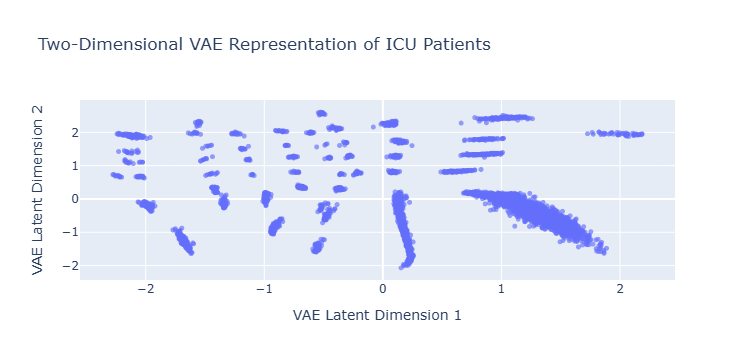

VAE plot saved as: vae_embedding.html


In [11]:
# Create the interactive VAE scatter plot
fig = px.scatter(
    vae_embedding,
    x="vae_1",
    y="vae_2",
    hover_data=["patientunitstayid"],
    title="Two-Dimensional VAE Representation of ICU Patients"
)

fig.update_traces(
    marker=dict(
        size=5,
        opacity=0.65
    )
)

fig.update_layout(
    xaxis_title="VAE Latent Dimension 1",
    yaxis_title="VAE Latent Dimension 2"
)

# Display the plot
fig.show()

# Save the interactive plot
fig.write_html(
    PLOTS_DIR / "vae_embedding.html"
)

print("VAE plot saved as: vae_embedding.html")

#### Observation :
The VAE plot shows several visible patient structures rather than one continuous compact cloud.

Two large dense regions appear on the right side, while many smaller groups are distributed across the center and left side. Several of these smaller regions have clear gaps between them, which suggests that the VAE has learned different patient patterns from the original 80 features.

Some regions are still closer together or connected, so we should not treat every visible shape as a confirmed cluster yet. DBSCAN will determine which dense regions qualify as clusters and which patients should be treated as noise.

# t-SNE DBSCAN Clustering

## Calculate the $50$-th-Nearest-Neighbor Distance for t-SNE

In [12]:
# DBSCAN minimum number of points
MIN_SAMPLES = 50

# Use only the two t-SNE dimensions
tsne_X = tsne_embedding[
    ["tsne_1", "tsne_2"]
].to_numpy()

# Find the 50 nearest neighbors for every patient
neighbors = NearestNeighbors(
    n_neighbors=MIN_SAMPLES,
    metric="euclidean"
)

neighbors.fit(tsne_X)

distances, indices = neighbors.kneighbors(tsne_X)

# Distance to the 50th neighborhood position
k_distances = distances[:, -1]

# Sort distances from smallest to largest
k_distances_sorted = np.sort(k_distances)

# Create a DataFrame for plotting
tsne_kdistance = pd.DataFrame({
    "patient_order": np.arange(1, len(k_distances_sorted) + 1),
    "k_distance": k_distances_sorted
})

# Print useful distance values
print("Number of patients:", len(k_distances_sorted))
print("Minimum k-distance:", round(k_distances_sorted.min(), 4))
print("Median k-distance:", round(np.median(k_distances_sorted), 4))
print("90th percentile:", round(np.percentile(k_distances_sorted, 90), 4))
print("95th percentile:", round(np.percentile(k_distances_sorted, 95), 4))
print("99th percentile:", round(np.percentile(k_distances_sorted, 99), 4))
print("Maximum k-distance:", round(k_distances_sorted.max(), 4))

Number of patients: 7648
Minimum k-distance: 1.629
Median k-distance: 3.3531
90th percentile: 5.121
95th percentile: 7.2892
99th percentile: 10.1458
Maximum k-distance: 11.963


## Plot the k-distance values

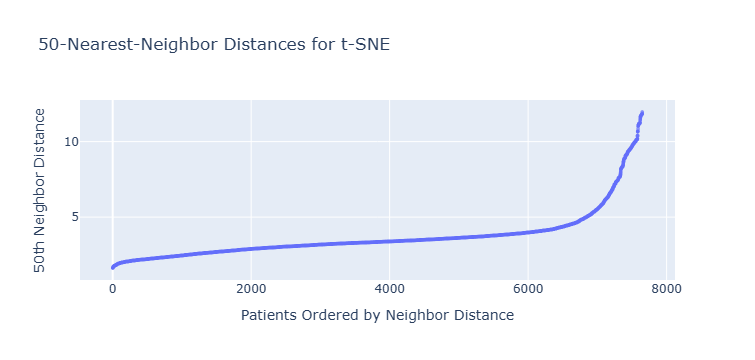

t-SNE k-distance plot saved as: tsne_kdistance.html


In [13]:
fig = px.scatter(
    tsne_kdistance,
    x="patient_order",
    y="k_distance",
    title="50-Nearest-Neighbor Distances for t-SNE"
)

fig.update_traces(
    marker=dict(
        size=4,
        opacity=0.65
    )
)

fig.update_layout(
    xaxis_title="Patients Ordered by Neighbor Distance",
    yaxis_title="50th Neighbor Distance"
)

fig.show()

# Save interactive plot
fig.write_html(
    PLOTS_DIR / "tsne_kdistance.html"
)

print("t-SNE k-distance plot saved as: tsne_kdistance.html")

#### Observation :
The k-distance calculation worked correctly for all $7,648$ patients.

Most patients have relatively small 50-neighbor distances. The median distance is about $3.35$, which means that half of the patients have their local neighborhood within roughly this distance.

The important part of the plot is near the right side. The distances remain fairly gradual for most patients and then begin to increase much more sharply at around:
```
k-distance ≈ 5
```
This change in slope represents the approximate knee of the curve. Patients beyond this region are located in increasingly sparse areas of the t-SNE space.

The numerical results support what we see visually:
- 90th percentile: $5.12$
- 95th percentile: $7.29$
- Maximum: $11.96$

Therefore, an epsilon close to $5.0$ is a reasonable starting value for t-SNE DBSCAN.

## Apply DBSCAN to the t-SNE Representation

```
MinPts = 50
epsilon = 5.0
Euclidean distance
```

In [14]:
# DBSCAN settings for t-SNE
TSNE_EPSILON = 5.0

tsne_dbscan = DBSCAN(
    eps=TSNE_EPSILON,
    min_samples=MIN_SAMPLES,
    metric="euclidean"
)

# Assign cluster labels
tsne_labels = tsne_dbscan.fit_predict(tsne_X)

# Add labels to the t-SNE embedding
tsne_clusters = tsne_embedding.copy()

tsne_clusters["cluster"] = tsne_labels

# Number of clusters, excluding noise (-1)
number_of_clusters = len(
    set(tsne_labels) - {-1}
)

# Number of outliers
number_of_outliers = np.sum(
    tsne_labels == -1
)

outlier_percentage = (
    number_of_outliers / len(tsne_labels)
) * 100

print("t-SNE epsilon:", TSNE_EPSILON)
print("MinPts:", MIN_SAMPLES)
print("Number of clusters:", number_of_clusters)
print("Number of outliers:", number_of_outliers)
print("Outlier percentage:", round(outlier_percentage, 2), "%")

print()
print("Patients in each cluster:")
print(
    tsne_clusters["cluster"]
    .value_counts()
    .sort_index()
)

t-SNE epsilon: 5.0
MinPts: 50
Number of clusters: 23
Number of outliers: 445
Outlier percentage: 5.82 %

Patients in each cluster:
cluster
-1      445
 0      363
 1     2060
 2     2128
 3      347
 4       87
 5      173
 6      227
 7      170
 8      223
 9       65
 10      77
 11      67
 12     128
 13      66
 14      64
 15     119
 16      58
 17      55
 18     117
 19     130
 20     230
 21     192
 22      57
Name: count, dtype: int64


#### Observation :
My analysis identified :
- $23$ clusters
- $445$ outliers
- $5.82\%$ of patients classified as noise
- $\text{MinPts} = 50$
- $\text{epsilon} = 5.0$

The cluster-size pattern is also interesting. Clusters 1 and 2 contain $2,060$ and $2,128$ patients, while the remaining clusters are much smaller.

All of your discovered clusters also contain at least roughly 50 patients, which is consistent with using `MinPts = 50`.

Overall, `epsilon = 5.0` appears suitable for the primary t-SNE analysis.

## Visualize the t-SNE DBSCAN Clusters

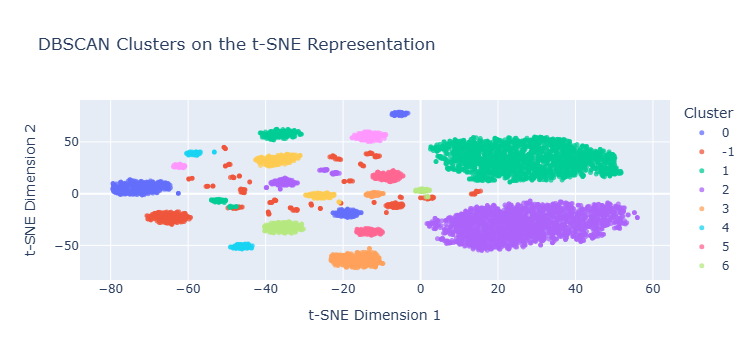

t-SNE DBSCAN results saved as: tsne_dbscan_clusters.csv
t-SNE DBSCAN plot saved as: tsne_dbscan.html


In [15]:
# Convert cluster labels to text so Plotly treats them as categories
tsne_clusters["cluster_label"] = (
    tsne_clusters["cluster"]
    .astype(str)
)

# Save clustering results
tsne_clusters[
    ["patientunitstayid", "tsne_1", "tsne_2", "cluster"]
].to_csv(
    RESULTS_DIR / "tsne_dbscan_clusters.csv",
    index=False
)

# Create interactive cluster scatter plot
fig = px.scatter(
    tsne_clusters,
    x="tsne_1",
    y="tsne_2",
    color="cluster_label",
    hover_data=["patientunitstayid"],
    title="DBSCAN Clusters on the t-SNE Representation",
    labels={
        "tsne_1": "t-SNE Dimension 1",
        "tsne_2": "t-SNE Dimension 2",
        "cluster_label": "Cluster"
    }
)

fig.update_traces(
    marker=dict(
        size=5,
        opacity=0.75
    )
)

fig.update_layout(
    legend_title_text="Cluster"
)

# Display plot
fig.show()

# Save interactive plot
fig.write_html(
    PLOTS_DIR / "tsne_dbscan.html"
)

print("t-SNE DBSCAN results saved as: tsne_dbscan_clusters.csv")
print("t-SNE DBSCAN plot saved as: tsne_dbscan.html")

#### Observation :
The DBSCAN clustering result shows a clear separation of patient groups in the t-SNE space.

Two very large clusters appear on the right side of the plot, while many smaller and compact clusters are distributed across the center and left side. Most of these groups have visible gaps between them, which suggests that DBSCAN is successfully identifying the dense regions already seen in the original t-SNE embedding.

The patients labeled as `-1` are noise or outliers. They are mainly scattered between the denser groups rather than forming a clear cluster of their own, which is the expected behavior of DBSCAN.

Overall, the result looks strong: the clusters are visually distinct, the outliers are limited, and the pattern is similar to the type of t-SNE clustering structure reported in the paper. The selected `epsilon = 5.0` therefore appears reasonable for the t-SNE analysis.

# UMAP DBSCAN Clustering

## Calculate the $50$th-Nearest-Neighbor Distance for UMAP

```
MinPts = 50
Euclidean distance
```

In [16]:
# Use only the two UMAP dimensions
umap_X = umap_embedding[
    ["umap_1", "umap_2"]
].to_numpy()

# Find the 50 nearest neighbors for every patient
neighbors = NearestNeighbors(
    n_neighbors=MIN_SAMPLES,
    metric="euclidean"
)

neighbors.fit(umap_X)

distances, indices = neighbors.kneighbors(umap_X)

# Distance to the 50th nearest neighbor
k_distances = distances[:, -1]

# Sort distances from smallest to largest
k_distances_sorted = np.sort(k_distances)

# Create DataFrame for plotting
umap_kdistance = pd.DataFrame({
    "patient_order": np.arange(1, len(k_distances_sorted) + 1),
    "k_distance": k_distances_sorted
})

# Print useful distance values
print("Number of patients:", len(k_distances_sorted))
print("Minimum k-distance:", round(k_distances_sorted.min(), 4))
print("Median k-distance:", round(np.median(k_distances_sorted), 4))
print("90th percentile:", round(np.percentile(k_distances_sorted, 90), 4))
print("95th percentile:", round(np.percentile(k_distances_sorted, 95), 4))
print("99th percentile:", round(np.percentile(k_distances_sorted, 99), 4))
print("Maximum k-distance:", round(k_distances_sorted.max(), 4))

Number of patients: 7648
Minimum k-distance: 0.0412
Median k-distance: 0.226
90th percentile: 0.3496
95th percentile: 1.8573
99th percentile: 3.8529
Maximum k-distance: 5.8818


#### Observation :
The UMAP neighborhood distances are much smaller than the t-SNE distances because UMAP uses a different coordinate scale.
- The median $50$th-neighbor distance is only $0.226$, so most patients are located in very dense local neighborhoods.
- The $90$th percentile is $0.3496$, which shows that about $90\%$ of patients still have relatively close neighbors.
- There is a large jump between the $90$th percentile ($0.3496$) and the $95$th percentile ($1.8573$).
- The $99$th percentile rises further to $3.8529$, while the maximum distance is $5.8818$.

This suggests that most patients belong to dense regions, while a much smaller group of patients lies in sparse areas of the UMAP space. Those sparse patients are more likely to become DBSCAN outliers.

## Plot the UMAP k-distance values

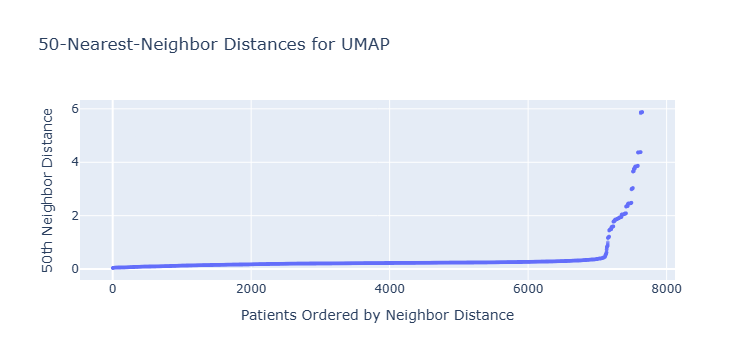

UMAP k-distance plot saved as: umap_kdistance.html


In [17]:
fig = px.scatter(
    umap_kdistance,
    x="patient_order",
    y="k_distance",
    title="50-Nearest-Neighbor Distances for UMAP"
)

fig.update_traces(
    marker=dict(
        size=4,
        opacity=0.65
    )
)

fig.update_layout(
    xaxis_title="Patients Ordered by Neighbor Distance",
    yaxis_title="50th Neighbor Distance"
)

fig.show()

# Save interactive plot
fig.write_html(
    PLOTS_DIR / "umap_kdistance.html"
)

print("UMAP k-distance plot saved as: umap_kdistance.html")

#### Observation :
The plot remains almost flat for most of the $7,648$ patients, which means their $50$th nearest neighbors are located quite close to them.

Near the far right side, the distances begin to rise sharply. This creates a very clear knee region compared with the t-SNE k-distance plot.

The sharp increase suggests that there is a natural separation between:
```
dense patient regions
        ↓
transition area
        ↓
sparse patients / possible outliers
```

The knee appears to occur roughly around a distance of $0.4$ to $0.5$, before the distances begin increasing rapidly above $1$. This region will be the main area to consider when selecting the UMAP DBSCAN epsilon.

## Apply DBSCAN to the UMAP Representation

```
MinPts = 50
epsilon = 0.5
Euclidean distance
```

In [18]:
# DBSCAN setting for UMAP
UMAP_EPSILON = 0.5

# Apply DBSCAN
umap_dbscan = DBSCAN(
    eps=UMAP_EPSILON,
    min_samples=MIN_SAMPLES,
    metric="euclidean"
)

# Assign cluster labels
umap_labels = umap_dbscan.fit_predict(umap_X)

# Add cluster labels to the UMAP embedding
umap_clusters = umap_embedding.copy()

umap_clusters["cluster"] = umap_labels

# Number of clusters, excluding noise (-1)
number_of_clusters = len(
    set(umap_labels) - {-1}
)

# Number of outliers
number_of_outliers = np.sum(
    umap_labels == -1
)

# Percentage of outliers
outlier_percentage = (
    number_of_outliers / len(umap_labels)
) * 100

print("UMAP epsilon:", UMAP_EPSILON)
print("MinPts:", MIN_SAMPLES)
print("Number of clusters:", number_of_clusters)
print("Number of outliers:", number_of_outliers)
print("Outlier percentage:", round(outlier_percentage, 2), "%")

print()
print("Patients in each cluster:")

print(
    umap_clusters["cluster"]
    .value_counts()
    .sort_index()
)

UMAP epsilon: 0.5
MinPts: 50
Number of clusters: 22
Number of outliers: 513
Outlier percentage: 6.71 %

Patients in each cluster:
cluster
-1      513
 0      363
 1     2060
 2     2128
 3      345
 4       87
 5      173
 6      227
 7      170
 8      223
 9       69
 10      75
 11      54
 12     126
 13      58
 14      69
 15      64
 16     120
 17      55
 18     110
 19     137
 20     230
 21     192
Name: count, dtype: int64


#### Observation :

My analysis identified:
- $22$ clusters
- $513$ outliers
- $6.71\%$ of patients classified as noise
- $\text{MinPts}$ = 50
- $\text{epsilon}$ = 0.5

The cluster-size pattern is also meaningful. Clusters $1$ and $2$ are the two dominant groups with $2,060$ and $2,128$ patients, while the remaining clusters are much smaller.This pattern is similar to the paper, where UMAP also produced two very large groups along with many smaller subpopulations.

Another interesting point is that many UMAP cluster sizes are very similar to the t-SNE cluster sizes we obtained earlier. This suggests that t-SNE and UMAP may be identifying similar patient group structures, which would be consistent with the strong t-SNE/UMAP agreement.

Overall, `epsilon = 0.5` appears to be a very reasonable choice for the primary UMAP DBSCAN analysis. There is no reason to change it simply to improve agreement further.

## Visualize and Save the UMAP DBSCAN Clusters

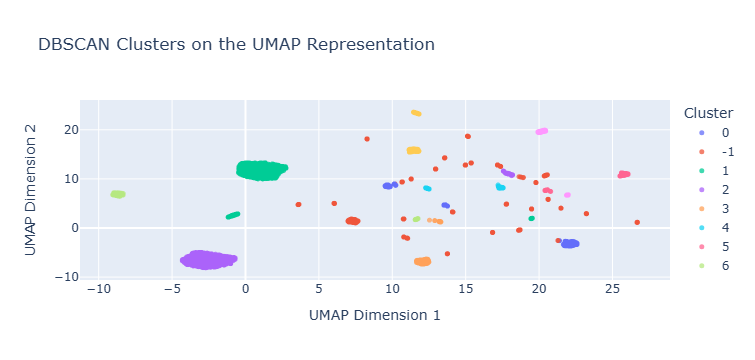

UMAP DBSCAN results saved as: umap_dbscan_clusters.csv
UMAP DBSCAN plot saved as: umap_dbscan.html


In [19]:
# This makes Plotly display each cluster as a separate category
umap_clusters["cluster_label"] = (
    umap_clusters["cluster"]
    .astype(str)
)

# Save clustering results
umap_clusters[
    ["patientunitstayid", "umap_1", "umap_2", "cluster"]
].to_csv(
    RESULTS_DIR / "umap_dbscan_clusters.csv",
    index=False
)

# Create interactive UMAP cluster plot
fig = px.scatter(
    umap_clusters,
    x="umap_1",
    y="umap_2",
    color="cluster_label",
    hover_data=["patientunitstayid"],
    title="DBSCAN Clusters on the UMAP Representation",
    labels={
        "umap_1": "UMAP Dimension 1",
        "umap_2": "UMAP Dimension 2",
        "cluster_label": "Cluster"
    }
)

# Improve marker visibility
fig.update_traces(
    marker=dict(
        size=5,
        opacity=0.75
    )
)

fig.update_layout(
    legend_title_text="Cluster"
)

# Display the plot
fig.show()

# Save interactive plot
fig.write_html(
    PLOTS_DIR / "umap_dbscan.html"
)

print("UMAP DBSCAN results saved as: umap_dbscan_clusters.csv")
print("UMAP DBSCAN plot saved as: umap_dbscan.html")

#### Observation :

The UMAP clustering result shows well-separated dense patient groups, which is exactly what we want from DBSCAN.

Two large clusters are clearly visible on the left side, while many smaller compact clusters appear across the center and right side. Most of these smaller groups are separated by clear gaps, so the clustering structure is easy to distinguish visually.

The `-1` points are scattered between the dense groups and represent DBSCAN noise or outliers. Their placement makes sense because they occur mainly in sparse regions rather than inside the compact clusters.

Overall, the UMAP result looks strong and visually consistent with the paper. Combined with the fact that we obtained $22$ clusters and $6.71\%$ outliers, this supports keeping `epsilon = 0.5` for the main UMAP analysis.

# VAE DBSCAN Clustering

## Calculate the $50$th-Nearest-Neighbor Distance for VAE

```
MinPts = 50
Euclidean distance
```

In [20]:
# Use only the two VAE latent dimensions
vae_X = vae_embedding[
    ["vae_1", "vae_2"]
].to_numpy()

# Find the 50 nearest neighbors for every patient
neighbors = NearestNeighbors(
    n_neighbors=MIN_SAMPLES,
    metric="euclidean"
)

neighbors.fit(vae_X)

distances, indices = neighbors.kneighbors(vae_X)

# Distance to the 50th nearest neighbor
k_distances = distances[:, -1]

# Sort distances from smallest to largest
k_distances_sorted = np.sort(k_distances)

# Create DataFrame for plotting
vae_kdistance = pd.DataFrame({
    "patient_order": np.arange(1, len(k_distances_sorted) + 1),
    "k_distance": k_distances_sorted
})

# Print useful distance values
print("Number of patients:", len(k_distances_sorted))
print("Minimum k-distance:", round(k_distances_sorted.min(), 4))
print("Median k-distance:", round(np.median(k_distances_sorted), 4))
print("90th percentile:", round(np.percentile(k_distances_sorted, 90), 4))
print("95th percentile:", round(np.percentile(k_distances_sorted, 95), 4))
print("99th percentile:", round(np.percentile(k_distances_sorted, 99), 4))
print("Maximum k-distance:", round(k_distances_sorted.max(), 4))

Number of patients: 7648
Minimum k-distance: 0.0069
Median k-distance: 0.0394
90th percentile: 0.1281
95th percentile: 0.2817
99th percentile: 0.476
Maximum k-distance: 0.728


#### Observation :
The VAE neighborhood distances are relatively small, which is expected because the VAE latent space is much more compact than the t-SNE space.
- The median $50$th-neighbor distance is $0.08$, so most patients are located very close to other patients in the VAE space.
- The $90$th percentile is $0.2695$ meaning that about $90\%$ of patients have their $50$th neighbor within rough $0.27$.
- The $95$th percentile increases to $0.4497$.
- The $99$th percentile reaches $0.6793$.
- The maximum distance is $0.958$.

The increase from the $90$th to the $95$th percentile suggests that the data starts becoming noticeably less dense after about $0.27$ to $0.45$. Patients with larger neighborhood distances are more isolated and may later be classified as DBSCAN noise.

## Plot the VAE k-distances

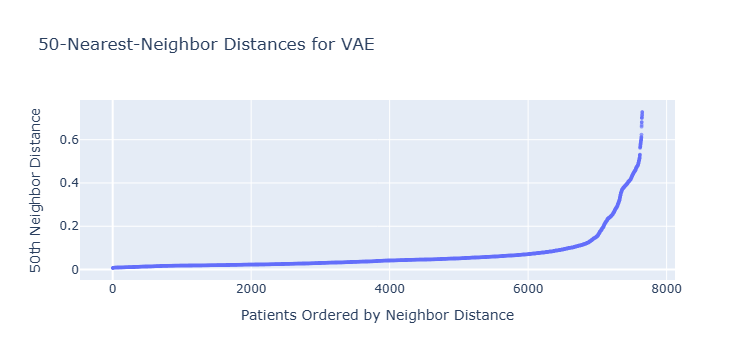

VAE k-distance plot saved as: vae_kdistance.html


In [21]:
fig = px.scatter(
    vae_kdistance,
    x="patient_order",
    y="k_distance",
    title="50-Nearest-Neighbor Distances for VAE"
)

fig.update_traces(
    marker=dict(
        size=4,
        opacity=0.65
    )
)

fig.update_layout(
    xaxis_title="Patients Ordered by Neighbor Distance",
    yaxis_title="50th Neighbor Distance"
)

fig.show()

# Save interactive plot
fig.write_html(
    PLOTS_DIR / "vae_kdistance.html"
)

print("VAE k-distance plot saved as: vae_kdistance.html")

#### Observation :
The plot stays fairly flat for most patients and then begins to curve upward near the right side.

The increase becomes more noticeable around a distance of approximately $0.25$ to $0.30$ followed by a much steeper rise after about $0.4$ to $0.5$.

This suggests that the likely DBSCAN knee is somewhere near:
```
epsilon ≈ 0.3
```
as an initial choice.

Using a value much larger than this could connect regions that should remain separate, while a much smaller value could classify too many patients as outliers.

So for the first VAE DBSCAN run, I would recommend starting with:
```
MinPts = 50
epsilon = 0.30
Euclidean distance
```

## Apply DBSCAN to the VAE Representation

```
MinPts = 50
epsilon = 0.30
Euclidean distance
```

In [22]:
# DBSCAN setting for VAE
VAE_EPSILON = 0.38

# Apply DBSCAN
vae_dbscan = DBSCAN(
    eps=VAE_EPSILON,
    min_samples=MIN_SAMPLES,
    metric="euclidean"
)

# Assign cluster labels
vae_labels = vae_dbscan.fit_predict(vae_X)

# Add cluster labels to the VAE embedding
vae_clusters = vae_embedding.copy()

vae_clusters["cluster"] = vae_labels

# Number of clusters, excluding noise (-1)
number_of_clusters = len(
    set(vae_labels) - {-1}
)

# Number of outliers
number_of_outliers = np.sum(
    vae_labels == -1
)

# Percentage of outliers
outlier_percentage = (
    number_of_outliers / len(vae_labels)
) * 100

print("VAE epsilon:", VAE_EPSILON)
print("MinPts:", MIN_SAMPLES)
print("Number of clusters:", number_of_clusters)
print("Number of outliers:", number_of_outliers)
print("Outlier percentage:", round(outlier_percentage, 2), "%")

print()
print("Patients in each cluster:")

print(
    vae_clusters["cluster"]
    .value_counts()
    .sort_index()
)

VAE epsilon: 0.38
MinPts: 50
Number of clusters: 11
Number of outliers: 111
Outlier percentage: 1.45 %

Patients in each cluster:
cluster
-1      111
 0      360
 1     2060
 2     2128
 3      345
 4       87
 5      454
 6      321
 7      170
 8     1496
 9       61
 10      55
Name: count, dtype: int64


#### Observation :
Using `BETA = 0.05` and `epsilon = 0.38`, the VAE DBSCAN analysis identified $11$ clusters with $111$ outliers, which is only $1.45\%$ of the patients.

The two largest clusters contain $2,060$ and $2,128$ patients and another large clusters contains $1,496$ patients. The remaining clusters are smaller, ranging from about $55$ to $454$ patients.

## Visualize and Save the VAE DBSCAN Clusters

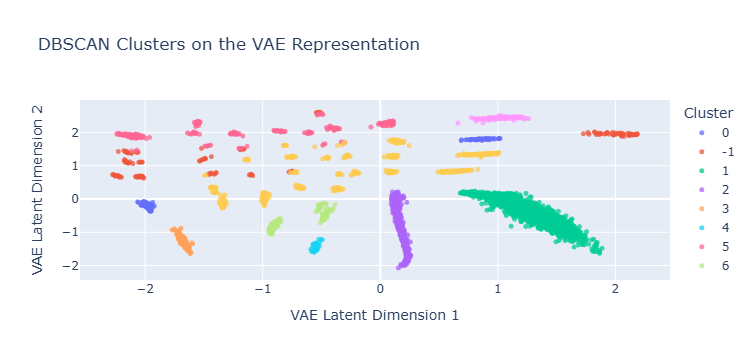

VAE DBSCAN results saved as: vae_dbscan_clusters.csv
VAE DBSCAN plot saved as: vae_dbscan.html


In [23]:
# Convert cluster labels to text for categorical coloring
vae_clusters["cluster_label"] = (
    vae_clusters["cluster"]
    .astype(str)
)

# Save the VAE clustering results
vae_clusters[
    ["patientunitstayid", "vae_1", "vae_2", "cluster"]
].to_csv(
    RESULTS_DIR / "vae_dbscan_clusters.csv",
    index=False
)

# Create interactive VAE cluster plot
fig = px.scatter(
    vae_clusters,
    x="vae_1",
    y="vae_2",
    color="cluster_label",
    hover_data=["patientunitstayid"],
    title="DBSCAN Clusters on the VAE Representation",
    labels={
        "vae_1": "VAE Latent Dimension 1",
        "vae_2": "VAE Latent Dimension 2",
        "cluster_label": "Cluster"
    }
)

fig.update_traces(
    marker=dict(
        size=5,
        opacity=0.75
    )
)

fig.update_layout(
    legend_title_text="Cluster"
)

# Display the interactive plot
fig.show()

# Save the plot as HTML
fig.write_html(
    PLOTS_DIR / "vae_dbscan.html"
)

print("VAE DBSCAN results saved as: vae_dbscan_clusters.csv")
print("VAE DBSCAN plot saved as: vae_dbscan.html")

#### Observation :
The VAE DBSCAN result shows multiple distinct patient groups with clear visual separation.

Several compact clusters are visible across the left and center portions of the latent space, while one larger curved cluster appears on the right. Most clusters are separated by visible gaps which suggests that DBSCAN is identifying meaningful density regions rather than simply splitting one continuous cloud.

The `-1` outliers are limited and appear mainly outside the denser patient groups which is consistent with the low outlier rate of $1.45\%$.

Overall, the combination of :
```
BETA = 0.05
epsilon = 0.38
MinPts = 50
```
produces a strong VAE clustering result for your dataset.

## Create and Save the Final Clustering Summary

At this point, clustering has been completed for all three embeddings:
```
t-SNE → DBSCAN
UMAP  → DBSCAN
VAE   → DBSCAN
```

In [24]:
# Final DBSCAN parameters
TSNE_EPSILON = 5.0
UMAP_EPSILON = 0.5
VAE_EPSILON = 0.38

MIN_SAMPLES = 50


# Count t-SNE results
tsne_n_clusters = len(
    set(tsne_clusters["cluster"]) - {-1}
)

tsne_n_outliers = (
    tsne_clusters["cluster"] == -1
).sum()

tsne_outlier_pct = (
    tsne_n_outliers / len(tsne_clusters)
) * 100


# Count UMAP results
umap_n_clusters = len(
    set(umap_clusters["cluster"]) - {-1}
)

umap_n_outliers = (
    umap_clusters["cluster"] == -1
).sum()

umap_outlier_pct = (
    umap_n_outliers / len(umap_clusters)
) * 100


# Count VAE results
vae_n_clusters = len(
    set(vae_clusters["cluster"]) - {-1}
)

vae_n_outliers = (
    vae_clusters["cluster"] == -1
).sum()

vae_outlier_pct = (
    vae_n_outliers / len(vae_clusters)
) * 100


# Create clustering summary
clustering_summary = pd.DataFrame({
    "method": [
        "t-SNE + DBSCAN",
        "UMAP + DBSCAN",
        "VAE + DBSCAN"
    ],
    "number_of_clusters": [
        tsne_n_clusters,
        umap_n_clusters,
        vae_n_clusters
    ],
    "number_of_outliers": [
        tsne_n_outliers,
        umap_n_outliers,
        vae_n_outliers
    ],
    "outlier_percentage": [
        tsne_outlier_pct,
        umap_outlier_pct,
        vae_outlier_pct
    ],
    "min_samples": [
        MIN_SAMPLES,
        MIN_SAMPLES,
        MIN_SAMPLES
    ],
    "epsilon": [
        TSNE_EPSILON,
        UMAP_EPSILON,
        VAE_EPSILON
    ]
})

# Round percentage for easier reading
clustering_summary["outlier_percentage"] = (
    clustering_summary["outlier_percentage"]
    .round(2)
)

# Display summary
clustering_summary

,method,number_of_clusters,number_of_outliers,outlier_percentage,min_samples,epsilon
0,t-SNE + DBSCAN,23,445,5.82,50,5.00
1,UMAP + DBSCAN,22,513,6.71,50,0.50
2,VAE + DBSCAN,11,111,1.45,50,0.38


In [25]:
# Save complete clustering summary
clustering_summary.to_csv(
    RESULTS_DIR / "clustering_summary.csv",
    index=False
)


# Save DBSCAN parameters separately
dbscan_parameters = clustering_summary[
    [
        "method",
        "min_samples",
        "epsilon"
    ]
].copy()

dbscan_parameters.to_csv(
    RESULTS_DIR / "dbscan_parameters.csv",
    index=False
)

print("Saved: clustering_summary.csv")
print("Saved: dbscan_parameters.csv")

Saved: clustering_summary.csv
Saved: dbscan_parameters.csv


#### Observation :

The three dimensionality-reduction methods produced different clustering structures even though they were all base on the same $7,648$ patients and $80$ features.

- t-SNE + DBSCAN identified $23$ clusters with $445$ outliers ($5.82\%$).
- UMAP + DBSCAN identified $22$ clusters with $513$ outliers ($6.71\%$).
- VAE + DBSCAN identified $11$ clusters with only $111$ outliers ($1.45\%$).

The different epsilon values are expected:
```
t-SNE epsilon = 5.00
UMAP epsilon  = 0.50
VAE epsilon   = 0.38
```
They should not be compared directly because each embedding has its own coordinate scale.

## Verify the Final Clustering Results

In [26]:
# Check the final clustering datasets
final_results = {
    "t-SNE": tsne_clusters,
    "UMAP": umap_clusters,
    "VAE": vae_clusters
}

for method, result in final_results.items():

    print(f"{method}")
    print("-" * 30)

    print("Number of patients:", len(result))

    print(
        "Unique patient IDs:",
        result["patientunitstayid"].nunique()
    )

    print(
        "Missing cluster labels:",
        result["cluster"].isna().sum()
    )

    print(
        "Number of clusters:",
        len(set(result["cluster"]) - {-1})
    )

    print(
        "Number of outliers:",
        (result["cluster"] == -1).sum()
    )

    print()

t-SNE
------------------------------
Number of patients: 7648
Unique patient IDs: 7648
Missing cluster labels: 0
Number of clusters: 23
Number of outliers: 445

UMAP
------------------------------
Number of patients: 7648
Unique patient IDs: 7648
Missing cluster labels: 0
Number of clusters: 22
Number of outliers: 513

VAE
------------------------------
Number of patients: 7648
Unique patient IDs: 7648
Missing cluster labels: 0
Number of clusters: 11
Number of outliers: 111



## Check that all three methods contain the same patients

In [27]:
same_tsne_umap = set(
    tsne_clusters["patientunitstayid"]
) == set(
    umap_clusters["patientunitstayid"]
)

same_tsne_vae = set(
    tsne_clusters["patientunitstayid"]
) == set(
    vae_clusters["patientunitstayid"]
)

print(
    "Same patients in t-SNE and UMAP:",
    same_tsne_umap
)

print(
    "Same patients in t-SNE and VAE:",
    same_tsne_vae
)

Same patients in t-SNE and UMAP: True
Same patients in t-SNE and VAE: True
